<a href="https://colab.research.google.com/github/Jayapriya49/Applied-AI/blob/main/ex_9B.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 22.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 51.8 MB/s eta 0:00:00
Upload your image


Saving Screenshot 2026-03-30 162735.png to Screenshot 2026-03-30 162735.png


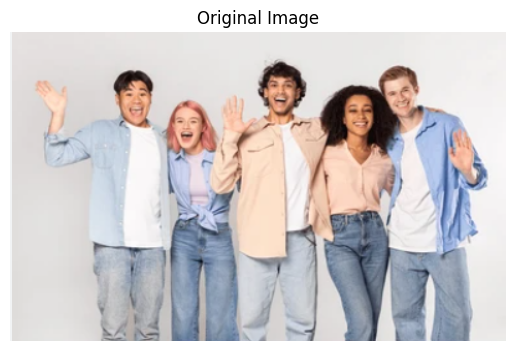

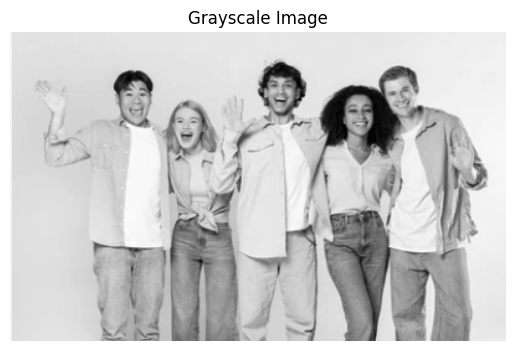

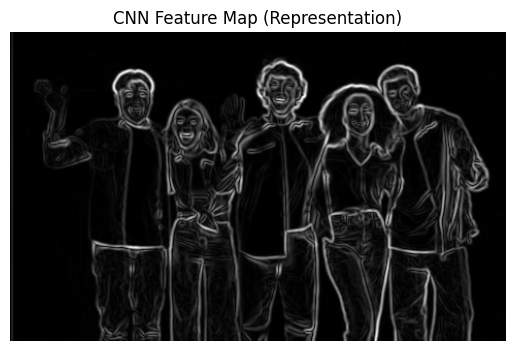

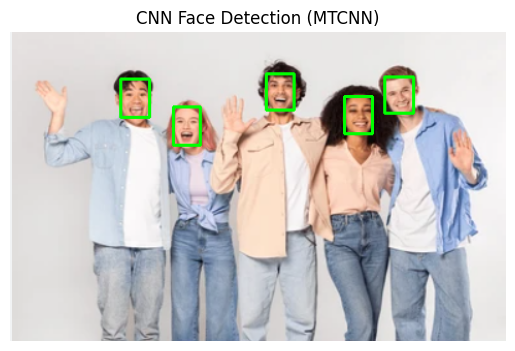

Number of faces detected: 5


In [1]:
# Install (run once)
!pip install mtcnn opencv-python matplotlib -q

# Imports
import cv2
import numpy as np
import matplotlib.pyplot as plt
from mtcnn import MTCNN
from google.colab import files

# -----------------------------
# Utility: Display Image
# -----------------------------
def render(image, title, gray_mode=False):
    plt.figure()
    if gray_mode:
        plt.imshow(image, cmap='gray')
    else:
        plt.imshow(image)
    plt.title(title)
    plt.axis("off")
    plt.show()

# -----------------------------
# Step 1: Load Image
# -----------------------------
def read_input():
    print("Upload your image")
    data = files.upload()
    name = list(data.keys())[0]
    image = cv2.imread(str(name))
    return image

# -----------------------------
# Step 2: Convert Formats
# -----------------------------
def convert_formats(img):
    rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    return rgb, gray

# -----------------------------
# Step 3: CNN Feature Simulation
# -----------------------------
def cnn_features(gray_img):
    dx = cv2.Sobel(gray_img, cv2.CV_64F, 1, 0, ksize=5)
    dy = cv2.Sobel(gray_img, cv2.CV_64F, 0, 1, ksize=5)

    # Different computation (not cv2.magnitude)
    feature = np.sqrt(np.square(dx) + np.square(dy))

    # Normalize manually
    feature = (feature - np.min(feature)) / (np.max(feature) - np.min(feature) + 1e-6)
    return feature

# -----------------------------
# Step 4: Face Detection (MTCNN)
# -----------------------------
def mtcnn_detect(rgb_img):
    model = MTCNN()
    return model.detect_faces(rgb_img)

# -----------------------------
# Step 5: Draw Boxes
# -----------------------------
def annotate_faces(rgb_img, detections):
    output_img = rgb_img.copy()

    for item in detections:
        x, y, w, h = item['box']

        # Ensure positive coords (robustness improvement)
        x, y = max(0, x), max(0, y)

        cv2.rectangle(output_img, (x, y), (x+w, y+h), (0, 255, 0), 2)

    return output_img

# -----------------------------
# MAIN EXECUTION
# -----------------------------
img = read_input()

rgb_img, gray_img = convert_formats(img)

# Original
render(rgb_img, "Original Image")

# Grayscale
render(gray_img, "Grayscale Image", gray_mode=True)

# CNN Feature Map
feature_img = cnn_features(gray_img)
render(feature_img, "CNN Feature Map (Representation)", gray_mode=True)

# Face Detection
faces = mtcnn_detect(rgb_img)

# Draw Bounding Boxes
final_img = annotate_faces(rgb_img, faces)

# Final Output
render(final_img, "CNN Face Detection (MTCNN)")

# Count
print("Number of faces detected:", len(faces))